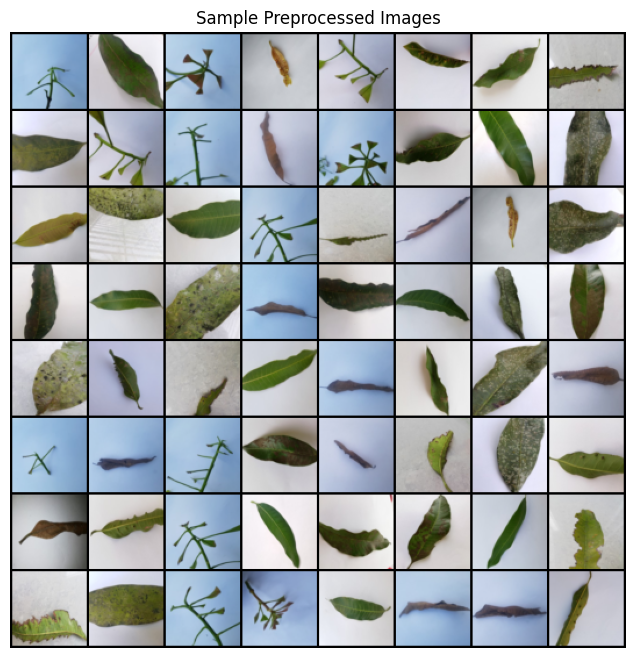

In [1]:
# 🧱 Section 1: Imports and Dataset Preprocessing

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, utils
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

# If using GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set seed
torch.manual_seed(42)

# Set constants
IMG_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 128
EPOCHS = 50

# Transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # normalize to [-1, 1]
])

# Load dataset
data_path = '/kaggle/input/mango-leaf-disease-dataset'
dataset = datasets.ImageFolder(root=data_path, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Show sample images
def show_images(images, title):
    grid = utils.make_grid(images[:64], nrow=8, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.title(title)
    plt.axis("off")
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.show()

data_iter = iter(dataloader)
sample_images, _ = next(data_iter)
show_images(sample_images, "Sample Preprocessed Images")


In [2]:
# 🧠 Section 2: Variational Autoencoder (VAE)

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),  # 64 → 32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 32 → 16
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 16 * 16),
            nn.Unflatten(1, (64, 16, 16)),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),   # 32 → 64
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = torch.chunk(h, 2, dim=1)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

Epoch 1, Loss: 0.1797
Epoch 2, Loss: 0.1587
Epoch 3, Loss: 0.1606
Epoch 4, Loss: 0.1780
Epoch 5, Loss: 0.1597
Epoch 6, Loss: 0.1611
Epoch 7, Loss: 0.1541
Epoch 8, Loss: 0.1500
Epoch 9, Loss: 0.1543
Epoch 10, Loss: 0.1574
Epoch 11, Loss: 0.1546
Epoch 12, Loss: 0.1421
Epoch 13, Loss: 0.1406
Epoch 14, Loss: 0.1532
Epoch 15, Loss: 0.1520
Epoch 16, Loss: 0.1735
Epoch 17, Loss: 0.1450
Epoch 18, Loss: 0.1512
Epoch 19, Loss: 0.1616
Epoch 20, Loss: 0.1691
Epoch 21, Loss: 0.1540
Epoch 22, Loss: 0.1199
Epoch 23, Loss: 0.1289
Epoch 24, Loss: 0.1362
Epoch 25, Loss: 0.1060
Epoch 26, Loss: 0.1225
Epoch 27, Loss: 0.1342
Epoch 28, Loss: 0.1255
Epoch 29, Loss: 0.1171
Epoch 30, Loss: 0.0991
Epoch 31, Loss: 0.1236
Epoch 32, Loss: 0.1181
Epoch 33, Loss: 0.1154
Epoch 34, Loss: 0.1218
Epoch 35, Loss: 0.1259
Epoch 36, Loss: 0.1099
Epoch 37, Loss: 0.1185
Epoch 38, Loss: 0.1108
Epoch 39, Loss: 0.1191
Epoch 40, Loss: 0.1101
Epoch 41, Loss: 0.1065
Epoch 42, Loss: 0.1052
Epoch 43, Loss: 0.1013
Epoch 44, Loss: 0.10

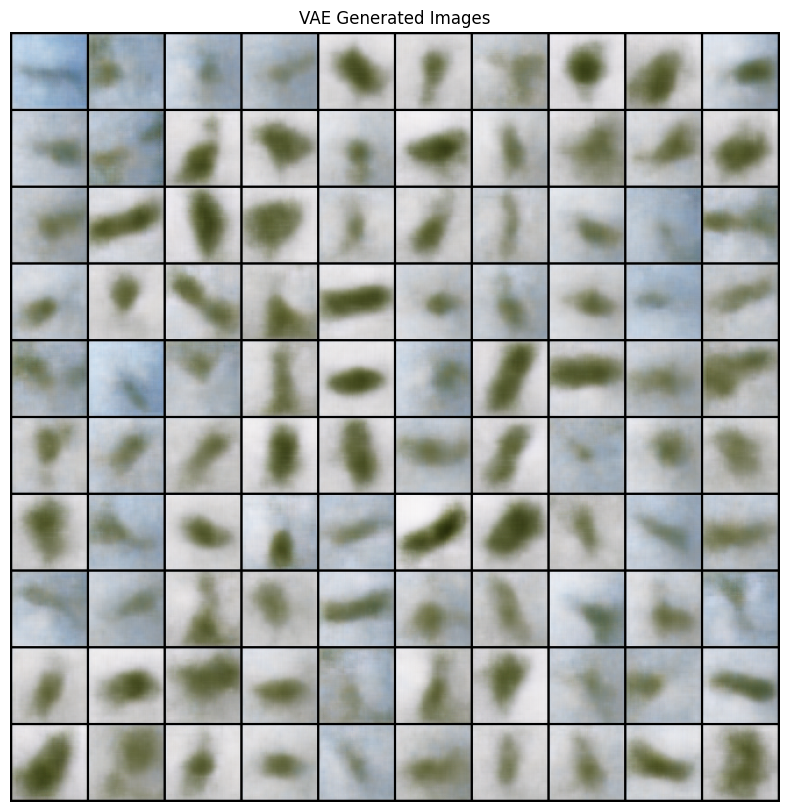

In [3]:
# 🧠 Section 3: VAE Training

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(50):
    for batch, _ in dataloader:
        batch = batch.to(device)
        recon_batch, mu, logvar = model(batch)

        mse_loss = nn.MSELoss()(recon_batch, batch)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = mse_loss + 0.0001 * kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

model.eval()
with torch.no_grad():
    z = torch.randn(100, 128).to(device)
    generated_images_vae = model.decoder(z).cpu()
    generated_images_vae = (generated_images_vae + 1) / 2  # Denormalize

# 🔒 Save VAE model
torch.save(model.state_dict(), "vae_model.pth")

# Save grid to file
utils.save_image(generated_images_vae, "vae_generated.png", nrow=10)

# Visualize the generated images
def show_images(img_tensor, title="Generated Images"):
    grid_img = utils.make_grid(img_tensor, nrow=10)
    npimg = grid_img.numpy()
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

show_images(generated_images_vae, "VAE Generated Images")


In [4]:
# 🧠 Section 4: DCGAN Generator & Discriminator

class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0),  # 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),  # 64x64
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

Epoch [1/50]  D Loss: 0.0234  G Loss: 6.4073
Epoch [2/50]  D Loss: 0.5762  G Loss: 3.3266
Epoch [3/50]  D Loss: 0.5855  G Loss: 1.9338
Epoch [4/50]  D Loss: 0.5701  G Loss: 3.7704
Epoch [5/50]  D Loss: 0.1842  G Loss: 3.3447
Epoch [6/50]  D Loss: 0.2876  G Loss: 2.8113
Epoch [7/50]  D Loss: 0.1082  G Loss: 4.3467
Epoch [8/50]  D Loss: 0.2326  G Loss: 3.4540
Epoch [9/50]  D Loss: 0.3132  G Loss: 2.8780
Epoch [10/50]  D Loss: 1.4659  G Loss: 7.3233
Epoch [11/50]  D Loss: 0.5800  G Loss: 2.0665
Epoch [12/50]  D Loss: 0.4482  G Loss: 2.6523
Epoch [13/50]  D Loss: 0.6156  G Loss: 2.9094
Epoch [14/50]  D Loss: 1.5211  G Loss: 0.9521
Epoch [15/50]  D Loss: 0.2895  G Loss: 3.6911
Epoch [16/50]  D Loss: 1.1908  G Loss: 6.9485
Epoch [17/50]  D Loss: 0.5060  G Loss: 3.7219
Epoch [18/50]  D Loss: 0.1944  G Loss: 2.9480
Epoch [19/50]  D Loss: 0.1323  G Loss: 3.7987
Epoch [20/50]  D Loss: 0.5072  G Loss: 2.1677
Epoch [21/50]  D Loss: 0.5325  G Loss: 2.8679
Epoch [22/50]  D Loss: 0.6599  G Loss: 0.86

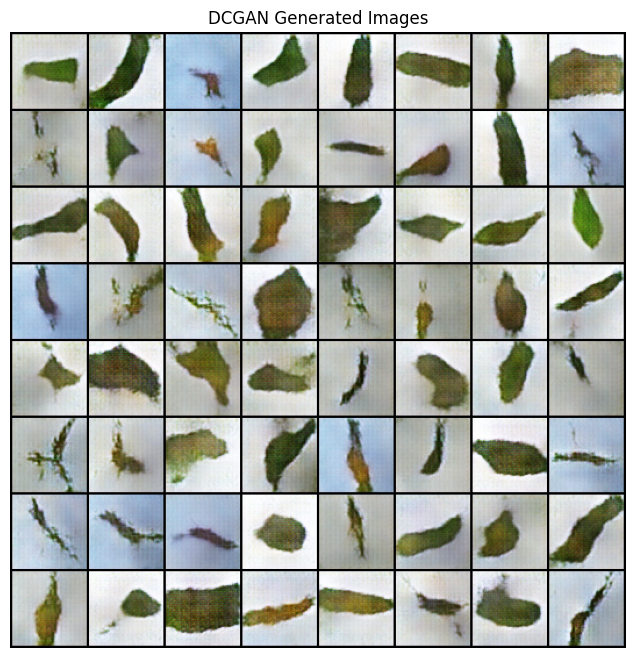

In [9]:
# 🏋️ Section 5: DCGAN Training

generator = Generator(LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
lr = 2e-4
g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

real_label = 1.0
fake_label = 0.0

for epoch in range(EPOCHS):
    for images, _ in dataloader:
        images = images.to(device)
        batch_size = images.size(0)

        # Train Discriminator
        discriminator.zero_grad()
        real_labels = torch.full((batch_size, 1), real_label, device=device)
        output_real = discriminator(images)
        d_loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = generator(noise)
        fake_labels = torch.full((batch_size, 1), fake_label, device=device)
        output_fake = discriminator(fake_images.detach())
        d_loss_fake = criterion(output_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        generator.zero_grad()
        output = discriminator(fake_images)
        g_loss = criterion(output, real_labels)
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

# 🔒 Save DCGAN Generator and Discriminator
torch.save(generator.state_dict(), "gan_generator.pth")
torch.save(discriminator.state_dict(), "gan_discriminator.pth")

# Generate 100 images
generator.eval()
with torch.no_grad():
    z = torch.randn(100, LATENT_DIM, 1, 1, device=device)
    generated_images_gan = generator(z).cpu()
    utils.save_image(generated_images_gan, "gan_generated.png", nrow=10, normalize=True)

# Visualize
show_images(generated_images_gan, "DCGAN Generated Images")

In [10]:
# 📊 SSIM between generated and real images

from skimage.metrics import structural_similarity as ssim
import torchvision.transforms.functional as TF

def compute_average_ssim(real_images, generated_images):
    real_images = real_images[:100]
    generated_images = generated_images[:100]

    ssim_scores = []
    for real, fake in zip(real_images, generated_images):
        real = TF.to_pil_image((real + 1) / 2)  # unnormalize
        fake = TF.to_pil_image((fake + 1) / 2)
        ssim_score = ssim(np.array(real), np.array(fake), multichannel=True, channel_axis=-1)
        ssim_scores.append(ssim_score)
    return np.mean(ssim_scores)

# Sample 100 real images
real_samples, _ = next(iter(DataLoader(dataset, batch_size=100, shuffle=True)))
real_samples = real_samples.cpu()

ssim_vae = compute_average_ssim(real_samples, generated_images_vae)
ssim_gan = compute_average_ssim(real_samples, generated_images_gan)

print(f"Average SSIM (VAE): {ssim_vae:.4f}")
print(f"Average SSIM (GAN): {ssim_gan:.4f}")

Average SSIM (VAE): 0.5001
Average SSIM (GAN): 0.3136


In [11]:
# 📏 Compute FID using torch-fidelity (install if needed)
!pip install torch-fidelity > /dev/null

from torch_fidelity import calculate_metrics

# Save generated + real samples to folders
import os
import torchvision.utils as vutils

os.makedirs("real", exist_ok=True)
os.makedirs("vae", exist_ok=True)
os.makedirs("gan", exist_ok=True)

# Save images
for i in range(100):
    vutils.save_image(real_samples[i], f"real/img_{i}.png", normalize=True)
    vutils.save_image(generated_images_vae[i], f"vae/img_{i}.png", normalize=True)
    vutils.save_image(generated_images_gan[i], f"gan/img_{i}.png", normalize=True)

# FID Evaluation
metrics_vae = calculate_metrics(input1='real', input2='vae', cuda=torch.cuda.is_available(), isc=False, fid=True)
metrics_gan = calculate_metrics(input1='real', input2='gan', cuda=torch.cuda.is_available(), isc=False, fid=True)

print(f"FID (VAE): {metrics_vae['frechet_inception_distance']:.2f}")
print(f"FID (GAN): {metrics_gan['frechet_inception_distance']:.2f}")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 24.12.0 requires rmm-cu12==24.12.*, but you have rmm-cu12 25.2.0 which is incompatible.


Creating feature extractor "inception-v3-compat" with features ['2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 176MB/s]
Extracting statistics from input 1
Looking for samples non-recursivelty in "real" with extensions png,jpg,jpeg
Found 100 samples
/usr/local/lib/python3.11/dist-packages/torch_fidelity/datasets.py:16: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  img = torch.ByteTensor(torch.ByteStorage.from_buffer(img.tobytes())).view(height, width, 3)
Processing samples                                                         
Extracting statist

FID (VAE): 398.48
FID (GAN): 292.66


Frechet Inception Distance: 292.66424494207797


Epoch [1/50]  D Loss: 0.0239  G Loss: 17.8509
Epoch [2/50]  D Loss: 0.4982  G Loss: 1.6548
Epoch [3/50]  D Loss: 0.5024  G Loss: 1.6871
Epoch [4/50]  D Loss: 0.5676  G Loss: 1.1943
Epoch [5/50]  D Loss: 0.2157  G Loss: 3.2111
Epoch [6/50]  D Loss: 0.2640  G Loss: 2.0065
Epoch [7/50]  D Loss: 0.3630  G Loss: 2.9083
Epoch [8/50]  D Loss: 0.3791  G Loss: 4.7614
Epoch [9/50]  D Loss: 0.5439  G Loss: 1.6057
Epoch [10/50]  D Loss: 1.3997  G Loss: 7.7462
Epoch [11/50]  D Loss: 0.5848  G Loss: 3.8805
Epoch [12/50]  D Loss: 0.6230  G Loss: 2.4364
Epoch [13/50]  D Loss: 0.6326  G Loss: 1.2097
Epoch [14/50]  D Loss: 1.3666  G Loss: 5.9752
Epoch [15/50]  D Loss: 0.4142  G Loss: 3.1035
Epoch [16/50]  D Loss: 0.4742  G Loss: 4.6221
Epoch [17/50]  D Loss: 0.6773  G Loss: 1.3162
Epoch [18/50]  D Loss: 0.7204  G Loss: 0.8477
Epoch [19/50]  D Loss: 0.1328  G Loss: 4.5488
Epoch [20/50]  D Loss: 1.4141  G Loss: 6.4769
Epoch [21/50]  D Loss: 0.2796  G Loss: 3.2442
Epoch [22/50]  D Loss: 0.9061  G Loss: 6.0

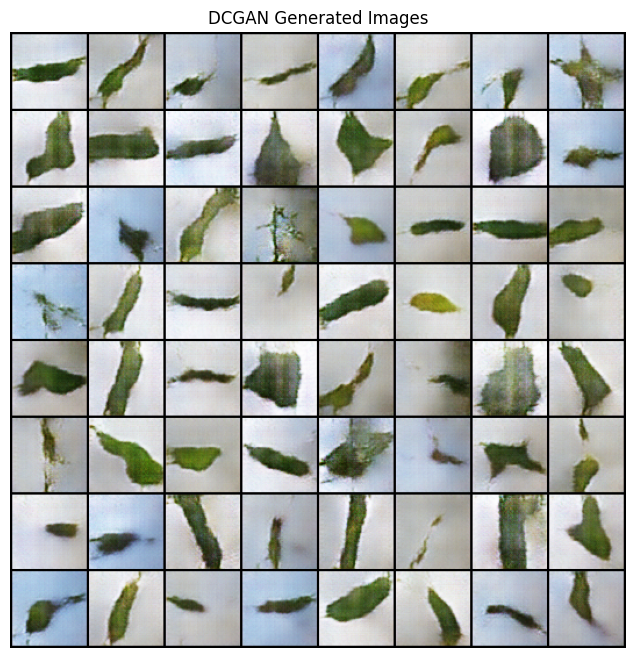

In [5]:
#{DONT RUN} 🏋️ Section 5: DCGAN Training

generator = Generator(LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()
lr = 2e-4
g_optimizer = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

real_label = 1.0
fake_label = 0.0

for epoch in range(EPOCHS):
    for images, _ in dataloader:
        images = images.to(device)
        batch_size = images.size(0)

        # Train Discriminator
        discriminator.zero_grad()
        real_labels = torch.full((batch_size, 1), real_label, device=device)
        output_real = discriminator(images)
        d_loss_real = criterion(output_real, real_labels)

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_images = generator(noise)
        fake_labels = torch.full((batch_size, 1), fake_label, device=device)
        output_fake = discriminator(fake_images.detach())
        d_loss_fake = criterion(output_fake, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        generator.zero_grad()
        output = discriminator(fake_images)
        g_loss = criterion(output, real_labels)
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

# 🔒 Save DCGAN Generator and Discriminator
torch.save(generator.state_dict(), "gan_generator.pth")
torch.save(discriminator.state_dict(), "gan_discriminator.pth")

# Generate 100 images
generator.eval()
with torch.no_grad():
    z = torch.randn(100, LATENT_DIM, 1, 1, device=device)
    generated_images_gan = generator(z).cpu()
    utils.save_image(generated_images_gan, "gan_generated.png", nrow=10, normalize=True)

# Visualize
show_images(generated_images_gan, "DCGAN Generated Images")